# Package

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mne
from mne.decoding import CSP as mne_csp
import sklearn
from sklearn.preprocessing import StandardScaler

In [2]:
print(f"mne version: {mne.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"sklearn version: {sklearn.__version__}")

mne version: 1.10.1
numpy version: 2.2.6
matplotlib version: 3.10.6
sklearn version: 1.7.2


# 112 CSP

In [3]:
def cov(trials):
    ''' Calculate the covariance for each trial and return their average '''
    ntrials = trials.shape[2]
    nsamples = trials.shape[1]
    covs = [ (trials[:,:,i] @ trials[:,:,i].T) / (nsamples-1) for i in range(ntrials) ]
    # covs = [ (trials[:,:,i] @ trials[:,:,i].T) / (nsamples) for i in range(ntrials) ]
    # print("covs:", len(covs))
    return np.mean(covs, axis=0)

def whitening(sigma):
    ''' Calculate a whitening matrix for covariance matrix sigma. '''
    U, l, _ = np.linalg.svd(sigma)
    return U @ np.diag(l ** -0.5)

def manual_csp(trials_r, trials_f):
    '''
    Calculate the CSP transformation matrix W.
    arguments:
        trials_r - Array (channels x samples x trials) containing right hand movement trials
        trials_f - Array (channels x samples x trials) containing foot movement trials
    returns:
        Mixing matrix W
    '''
    cov_r = cov(trials_r)
    cov_f = cov(trials_f)

    ### Modify
    sigma_total = cov_r + cov_f
    eigenvalues, U = np.linalg.eigh(sigma_total)
    eps = 1e-10
    P = U @ np.diag((eigenvalues + eps) ** -0.5) @ U.T
    transformed_cov = P.T @ cov_r @ P
    evals, B = np.linalg.eigh(transformed_cov)
    ix = np.argsort(evals)[::-1]
    W = (P @ B)[:, ix]
    W = W.T

    ### Origin
    # P = whitening(cov_r + cov_f)
    # sigma = cov_r + cov_f
    # U, l, _ = np.linalg.svd(sigma)
    # eps = 1e-10
    # P =  np.diag((l+eps) ** -0.5) @ U.T
    # transformed_cov = P.T.dot(cov_r).dot(P)
    # B, _, _ = np.linalg.svd( transformed_cov )
    # # print("B:", B.shape)
    # W = P.dot(B)

    return W

def apply_mix(W, trials):
    ''' Apply a mixing matrix to each trial (basically multiply W with the EEG signal matrix)'''
    ntrials = trials.shape[2]
    nsamples = trials.shape[1]
    nchannels = trials.shape[0]
    trials_csp = np.zeros((nchannels, nsamples, ntrials))
    W_select = W[[0, -1],:]
    for i in range(ntrials):
        trials_csp[:,:,i] = W_select.T.dot(trials[:,:,i])
    return trials_csp

# 提取特徵：取第一行與最後一行濾波器，計算投影後的對數方差
def extract_features(W, data):
    # data: (trials, channels, samples)
    feat = []
    for i in range(data.shape[0]):
        # 投影: (2, channels) @ (channels, samples) -> (2, samples)
        z = W[[0, -1], :] @ data[i]
        var = np.var(z, axis=1)
        feat.append(np.log(var))
    return np.array(feat)

# 114 CSP

In [4]:
class MyStableCSP:
    def __init__(self, n_components=4, reg=1e-6):
        self.n_components = n_components
        self.reg = reg # 我們推導中的 gamma
        self.filters_ = None

    def trace_normalization(self, X):
        X_T = np.transpose(X, (0,2,1))
        cov = X @ X_T
        trace = np.trace(cov, axis1=1, axis2=2).reshape(cov.shape[0], 1, 1)
        return cov/trace

    def covarianc_mean(self, trials):
        ''' Calculate the covariance for each trial and return their average '''
        ntrials = trials.shape[0]
        nsamples = trials.shape[2]
        covs = [ (trials[i,:,:] @ trials[i,:,:].T) / (nsamples-1) for i in range(ntrials) ]
        return np.mean(covs, axis=0)

    def fit(self, epochs_data, labels):
        # 1. 準備數據：拆分兩類
        class1 = epochs_data[labels == 0]
        class2 = epochs_data[labels == 1]
        class1 = self.trace_normalization(class1)
        class2 = self.trace_normalization(class2)

        # 2. 計算各自的平均協方差矩陣
        # (epochs, channels, times) -> (channels, channels)
        cov_1 = self.covarianc_mean(class1)
        cov_2 = self.covarianc_mean(class2)

        sigma_total = cov_1 + cov_2
        eigenvalues, U = np.linalg.eigh(sigma_total)
        eps = 1e-10
        P = U @ np.diag((eigenvalues + eps) ** -0.5) @ U.T
        transformed_cov = P.T @ cov_1 @ P
        evals, B = np.linalg.eigh(transformed_cov)
        ix = np.argsort(evals)[::-1]

        # 3. 選擇csp
        half = self.n_components // 2
        head_idx = ix[:self.n_components-half]
        tail_idx = ix[-half:]
        ix_selected = np.concatenate([head_idx, tail_idx])
        W = (P @ B)[:, ix_selected]
        W = W.T
        self.filters_ = W
        return self

    def transform(self, epochs_data):
        # 應用空間濾波器：Z = W * X
        feat = []
        for e in epochs_data:
            feat.append(np.dot(self.filters_, e))
        feat = np.array(feat)
        feat_var = np.var(feat, axis=2)
        feat_log = np.log(feat_var)
        return feat_log

# 1. 產生隨機模擬訊號

In [5]:
np.random.seed(42)
n_channels, n_samples, n_trials = 4, 500, 40
# 產生兩類訊號，分別在 Channel 0 和 Channel 3 有較強能量
data_r = np.random.randn(n_trials, n_channels, n_samples)
data_r[:, 0, :] *= 2.0  # 第一類在第 0 通道強
data_f = np.random.randn(n_trials, n_channels, n_samples)
data_f[:, 3, :] *= 2.0  # 第二類在第 3 通道強

# 標準化(平均0，標準差1)
def standard_scaler(X):
    """
    對資料進行 Z-score 標準化 (平均 0, 標準差 1)
    X: ndarray, 形狀為 (ch, samples, trials)
    """
    # 計算每個特徵（Column）的平均值與標準差
    mean = np.mean(X, axis=2).reshape(n_trials, n_channels, 1)
    mean = np.repeat(mean, n_samples, axis=2)
    std = np.std(X, axis=2).reshape(n_trials, n_channels, 1)
    std = np.repeat(std, n_samples, axis=2)

    # 防止標準差為 0 導致除以零的錯誤
    std[std == 0] = 1.0

    # 執行轉換
    X_scaled = (X - mean) / std
    return X_scaled

def trace_normalization(X):
    X_T = np.transpose(X, (0,2,1))
    cov = X @ X_T
    trace = np.trace(cov, axis1=1, axis2=2).reshape(40, 1, 1)
    return cov/trace

# data_r = trace_normalization(data_r)
# data_f = trace_normalization(data_f)
print(f"data_r shape: {data_r.shape}")
print(f"data_f shape: {data_f.shape}")

# 為了符合手寫函數的輸入 (ch, samples, trials)
train_r = np.transpose(data_r, (1, 2, 0))
train_f = np.transpose(data_f, (1, 2, 0))
print(f"train_r shape: {train_r.shape}")
print(f"train_f shape: {train_f.shape}")

# 計算variance
# train_r_var = np.var(train_r, axis=1)
# train_f_var = np.var(train_f, axis=1)
# print(f"train_r variance shape: {train_r_var.shape}")
# print(f"train_f variance shape: {train_f_var.shape}")
# print(f"train_r variance is 1: {np.allclose(train_r_var, 1)}")
# print(f"train_f variance is 1: {np.allclose(train_f_var, 1)}")

data_r shape: (40, 4, 500)
data_f shape: (40, 4, 500)
train_r shape: (4, 500, 40)
train_f shape: (4, 500, 40)


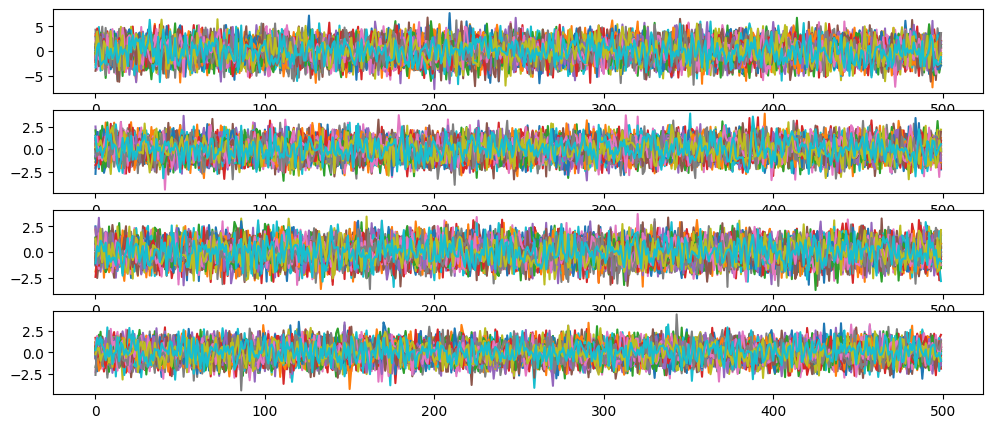

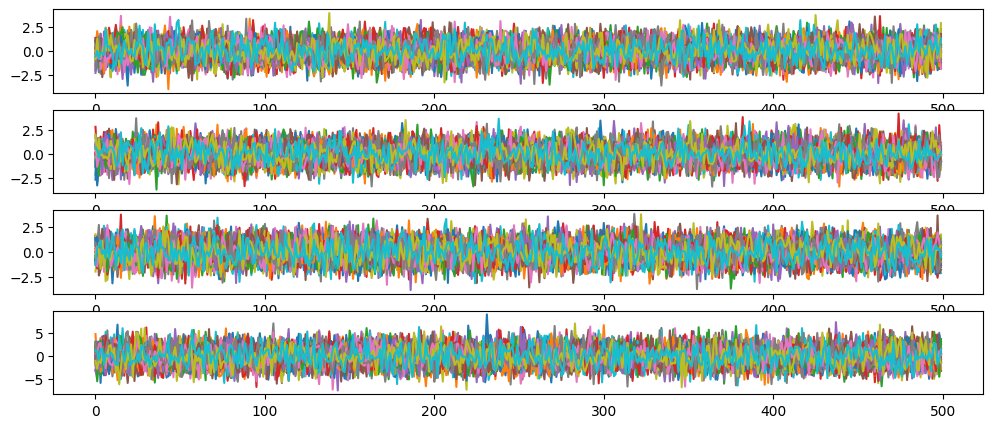

In [6]:
fig, ax = plt.subplots(4, 1, figsize=(12, 5))
for trs in range(n_trials):
    ax[0].plot(data_r[trs, 0, :])
    ax[1].plot(data_r[trs, 1, :])
    ax[2].plot(data_r[trs, 2, :])
    ax[3].plot(data_r[trs, 3, :])

fig, ax = plt.subplots(4, 1, figsize=(12, 5))
for trs in range(n_trials):
    ax[0].plot(data_f[trs, 0, :])
    ax[1].plot(data_f[trs, 1, :])
    ax[2].plot(data_f[trs, 2, :])
    ax[3].plot(data_f[trs, 3, :])

# 2. 執行 CSP 並計算特徵 (Variance)

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.feature_selection import f_classif

def calculate_separation_metrics(X, y):
    # 1. 計算 Fisher Score
    f_scores, p_values = f_classif(X, y)
    f_score_2norm = np.sum(f_scores**2)**0.5

    # 2. 計算 Silhouette Score
    s_score = silhouette_score(X, y)

    # 3. 計算 Davies-Bouldin Index
    db_index = davies_bouldin_score(X, y)

    return f_score_2norm, s_score, db_index

Computing rank from data with rank=None
    Using tolerance 0.28 (2.2e-16 eps * 4 dim * 3.2e+14  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
feat_manual_r shape: (40, 2)
feat_manual_f shape: (40, 2)
feat_mne_r shape: (40, 2)
feat_mne_f shape: (40, 2)
feat_114_r shape: (40, 4)
feat_114_f shape: (40, 4)
--- Manual ---
Fisher Score: 14343.2773, Silhouette: 0.9448, DBI: 0.0761
--- MNE 後 ---
Fisher Score: 14367.5462, Silhouette: 0.9449, DBI: 0.0760
--- 114 後 ---
Fisher Score: 14338.2838, Silhouette: 0.9151, DBI: 0.1176


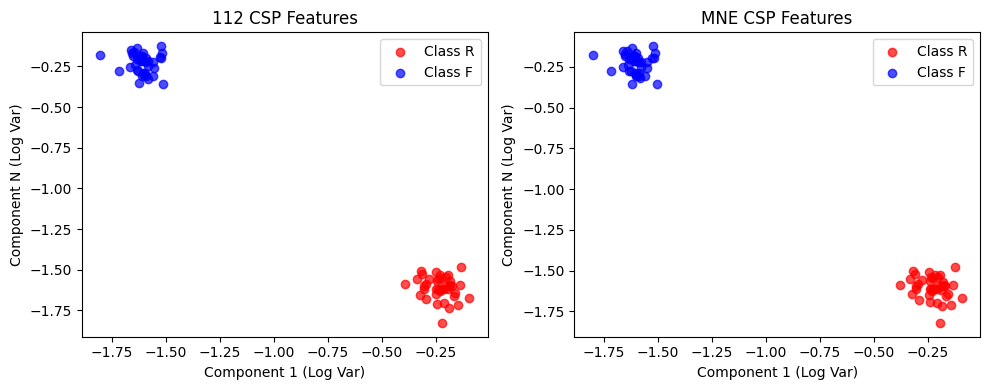

In [8]:
# --- 3. 執行 CSP 並計算特徵 (Variance) ---

# 手寫 CSP
W_manual = manual_csp(train_r, train_f)

feat_manual_r = extract_features(W_manual, data_r)
feat_manual_f = extract_features(W_manual, data_f)


# MNE CSP (對照組)
# MNE 輸入格式為 (trials, channels, samples)，類別標籤 0 與 1
labels = np.array([0]*n_trials + [1]*n_trials)
full_data = np.concatenate([data_r, data_f], axis=0)
csp_mne = mne_csp(n_components=2, reg=None, log=True, norm_trace=False)
csp_mne.fit(full_data, labels)
feat_mne_r = csp_mne.transform(data_r)
feat_mne_f = csp_mne.transform(data_f)

# 114 csp
my_csp = MyStableCSP(n_components=4, reg=1e-9)
my_csp.fit(full_data, labels)
my_filters = my_csp.filters_
feat_114_r = my_csp.transform(data_r)
feat_114_f = my_csp.transform(data_f)

# shape check
print(f"feat_manual_r shape: {feat_manual_r.shape}")
print(f"feat_manual_f shape: {feat_manual_f.shape}")
print(f"feat_mne_r shape: {feat_mne_r.shape}")
print(f"feat_mne_f shape: {feat_mne_f.shape}")
print(f"feat_114_r shape: {feat_114_r.shape}")
print(f"feat_114_f shape: {feat_114_f.shape}")

# Metrix
labels = np.array([0]*n_trials + [1]*n_trials)
feat_manual_all = np.concatenate((feat_manual_r, feat_manual_f), axis=0)
feat_mne_all = np.concatenate((feat_mne_r, feat_mne_f), axis=0)
feat_114_all = np.concatenate((feat_114_r, feat_114_f), axis=0)
metrix_manual = calculate_separation_metrics(feat_manual_all, labels)
metrix_mne = calculate_separation_metrics(feat_mne_all, labels)
metrix_114 = calculate_separation_metrics(feat_114_all, labels)
print(f"--- Manual ---")
print(f"Fisher Score: {metrix_manual[0]:.4f}, Silhouette: {metrix_manual[1]:.4f}, DBI: {metrix_manual[2]:.4f}")
print(f"--- MNE 後 ---")
print(f"Fisher Score: {metrix_mne[0]:.4f}, Silhouette: {metrix_mne[1]:.4f}, DBI: {metrix_mne[2]:.4f}")
print(f"--- 114 後 ---")
print(f"Fisher Score: {metrix_114[0]:.4f}, Silhouette: {metrix_114[1]:.4f}, DBI: {metrix_114[2]:.4f}")

# --- 4. 繪圖比較 ---

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# 手寫結果
ax[0].scatter(feat_manual_r[:, 0], feat_manual_r[:, 1], color='red', label='Class R', alpha=0.7)
ax[0].scatter(feat_manual_f[:, 0], feat_manual_f[:, 1], color='blue', label='Class F', alpha=0.7)
ax[0].set_title("112 CSP Features")
ax[0].set_xlabel("Component 1 (Log Var)")
ax[0].set_ylabel("Component N (Log Var)")
ax[0].legend()

# 114
# ax[1].scatter(feat_114_r[:, 0], feat_114_r[:, 1], color='red', label='Class R', alpha=0.7)
# ax[1].scatter(feat_114_f[:, 0], feat_114_f[:, 1], color='blue', label='Class F', alpha=0.7)
# ax[1].set_title("114 CSP Features")
# ax[1].set_xlabel("Component 1 (Log Var)")
# ax[1].set_ylabel("Component N (Log Var)")
# ax[1].legend()

# MNE 結果
ax[1].scatter(feat_mne_r[:, 0], feat_mne_r[:, -1], color='red', label='Class R', alpha=0.7)
ax[1].scatter(feat_mne_f[:, 0], feat_mne_f[:, -1], color='blue', label='Class F', alpha=0.7)
ax[1].set_title("MNE CSP Features")
ax[1].set_xlabel("Component 1 (Log Var)")
ax[1].set_ylabel("Component N (Log Var)")
ax[1].legend()

plt.tight_layout()
plt.show()

# end